### **Initial Functions**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import csv
from scipy import spatial
from sko.PSO import PSO, PSO_TSP

def ReadTsp(fn):
    cities = []
    with open(fn + ".tsp", "rt") as f:
        reader = csv.reader(f, delimiter=" ", skipinitialspace=True)
        coordinates = False
        for row in reader:
            if not row or row[0] == "EOF": break
            if coordinates: cities.append((float(row[1]), float(row[2])))
            elif row[0] == "NODE_COORD_SECTION": coordinates = True
    return np.array(cities)

points_coordinate = ReadTsp('berlin52')
num_points = len(points_coordinate)
optimal_val = 7542


dist_matrix = spatial.distance.cdist(points_coordinate, points_coordinate, metric='euclidean')
dist_matrix = np.rint(dist_matrix).astype(int)

def cal_total_distance(routine):
    num_cities = len(routine)
    return sum([dist_matrix[routine[i % num_cities], routine[(i + 1) % num_cities]] for i in range(num_cities)])

# Our adaptation of the teacher's ROV function
def rov_objective(p):
    route = np.argsort(p)
    return cal_total_distance(route)


In [ ]:
optimal_val = 7542
def run_experiment(algo_type, pop, iters, w, c1, c2, rounds=10, title_suffix=""):
    runtimes = []
    final_results = []
    
    all_best_histories = []
    all_avg_histories = []
    
    for r in range(rounds):
        start = time.time()
        
        if algo_type == 'Discrete':
            model = PSO_TSP(func=cal_total_distance, n_dim=num_points, size_pop=pop, max_iter=iters, w=w, c1=c1, c2=c2)
        else: # ROV
            model = PSO(func=rov_objective, n_dim=num_points, pop=pop, max_iter=iters, lb=[0]*num_points, ub=[100]*num_points, w=w, c1=c1, c2=c2)
            model.record_mode = True 
        
        best_x, best_y = model.run()
        runtimes.append(time.time() - start)
        
        final_val = best_y[0] if isinstance(best_y, (list, np.ndarray)) else best_y
        final_results.append(final_val)
        
        round_best = []
        round_avg = []
        
        if algo_type == 'ROV':
            hist_Y = model.record_value['Y']
            for fits in hist_Y:
                round_best.append(np.min(fits))
                round_avg.append(np.mean(fits))
        else:
            hist_Y = model.gbest_y_hist
            for fits in hist_Y:
                if isinstance(fits, (list, np.ndarray)):
                    round_best.append(np.min(fits))
                    round_avg.append(np.mean(fits))
                else:
                    round_best.append(fits)
                    round_avg.append(fits)
        
        all_best_histories.append(round_best)
        all_avg_histories.append(round_avg)

    avg_min_fit = np.mean(all_best_histories, axis=0)
    std_min_fit = np.std(all_best_histories, axis=0)
    avg_pop_avg = np.mean(all_avg_histories, axis=0)
    
    min_fit_all_rounds = np.min(final_results)
    gap = ((min_fit_all_rounds - optimal_val) / optimal_val) * 100
    
    plt.figure(figsize=(10, 5))
    iters_arr = np.arange(len(avg_min_fit))
    
    plt.plot(iters_arr, avg_pop_avg, label='Population Average (Mean)', color='blue', linestyle='--', alpha=0.6)
    plt.plot(iters_arr, avg_min_fit, label='Best Fitness (Mean)', color='green', linewidth=2)
    plt.fill_between(iters_arr, np.maximum(avg_min_fit - std_min_fit, 1e-15), 
                     avg_min_fit + std_min_fit, color='green', alpha=0.15)
    
    plt.yscale('log')
    plt.title(f"Detailed Evolution: {algo_type}\n{title_suffix}", fontweight='bold')
    plt.xlabel('Iterations')
    plt.ylabel('Total Distance (Log Scale)')
    plt.legend()
    plt.grid(True, which="both", linestyle=':', alpha=0.5)
    plt.show()

    return {
        'avg_fit': np.mean(final_results),
        'min_fit': min_fit_all_rounds,
        'std_fit': np.std(final_results),
        'avg_time': np.mean(runtimes),
        'gap': gap,
        'hist_avg_min': avg_min_fit,
        'hist_std_min': std_min_fit,
        'hist_pop_avg': avg_pop_avg
    }

def plot_final_comparison(results_master, var_name, filename):
    """Genera un gràfic comparant el Millor Fitness i el Fitness Mitjà de la població."""
    plt.figure(figsize=(12, 8))
    
    colors = plt.cm.get_cmap('tab10', len(results_master))
    
    for i, (val, res) in enumerate(results_master.items()):
        iters = np.arange(len(res['hist_avg_min']))
        c = colors(i)
        
        plt.plot(iters, res['hist_avg_min'], 
                 label=f'{var_name}={val} (Best)', 
                 color=c, linewidth=2)
        
        if 'hist_pop_avg' in res:
            plt.plot(iters, res['hist_pop_avg'], 
                     color=c, linestyle='--', alpha=0.5, linewidth=1.5,
                     label=f'{var_name}={val} (Pop Avg)')
        
        plt.fill_between(iters, 
                         res['hist_avg_min'] - res['hist_std_min'], 
                         res['hist_avg_min'] + res['hist_std_min'], 
                         color=c, alpha=0.1)

    plt.yscale('log')
    plt.xlabel('Iterations', fontsize=12)
    plt.ylabel('Fitness (Log Scale)', fontsize=12)
    plt.title(f'Comparative Analysis: {var_name}\nSolid = Best Fitness | Dashed = Population Average', 
              fontweight='bold', fontsize=14)
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    
    plt.grid(True, which="both", linestyle=':', alpha=0.4)
    plt.tight_layout()
    
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

### **Testing on w, c1 & c2**

Initializing Parameter Sweep - Berlin52 TSP
Settings: Pop=100, Iter=500, Rounds=30


>>> Testing Algorithm: ROV
Running config: Standard (Balanced) (w:0.8, c1:1.0, c2:1.0)... 

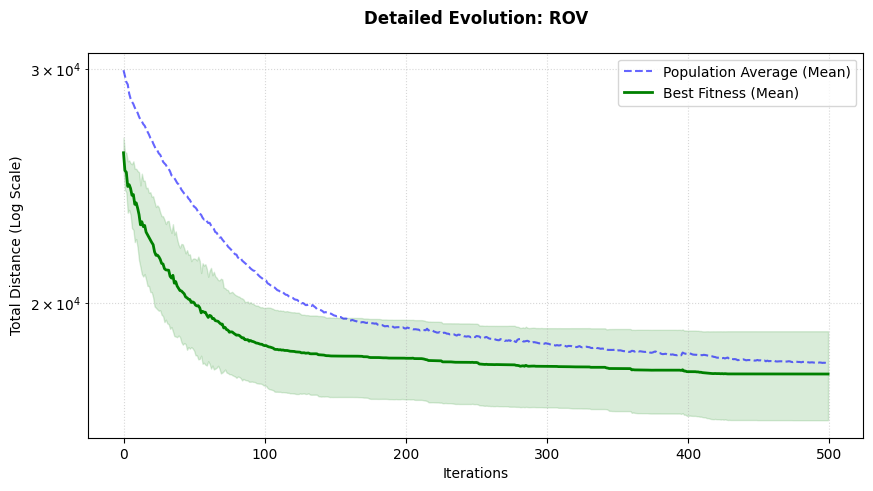

Done! | Gap: 98.87% | Time: 0.78s
Running config: High Inertia (Exploration) (w:0.9, c1:0.5, c2:0.6)... 

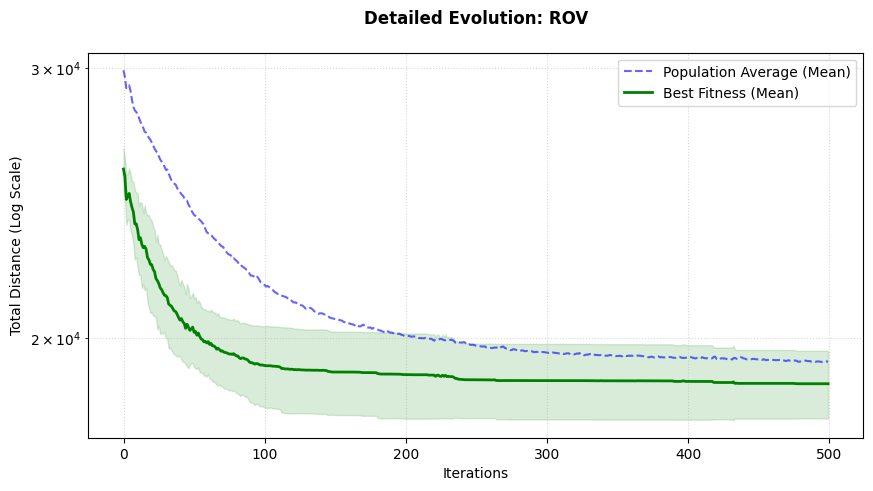

Done! | Gap: 122.90% | Time: 0.80s
Running config: High Acceleration (Convergence) (w:0.6, c1:1.8, c2:1.8)... 

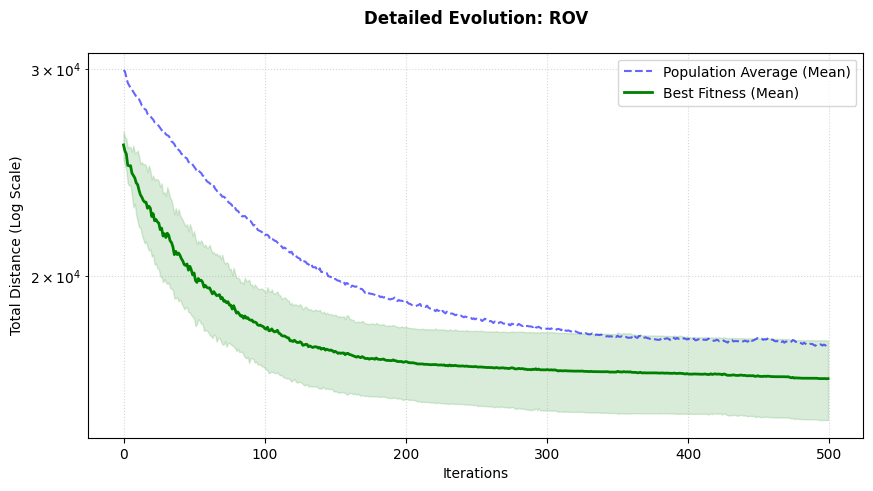

Done! | Gap: 74.00% | Time: 0.77s
Running config: Highly Social (Global Influence) (w:0.7, c1:0.5, c2:2.5)... 

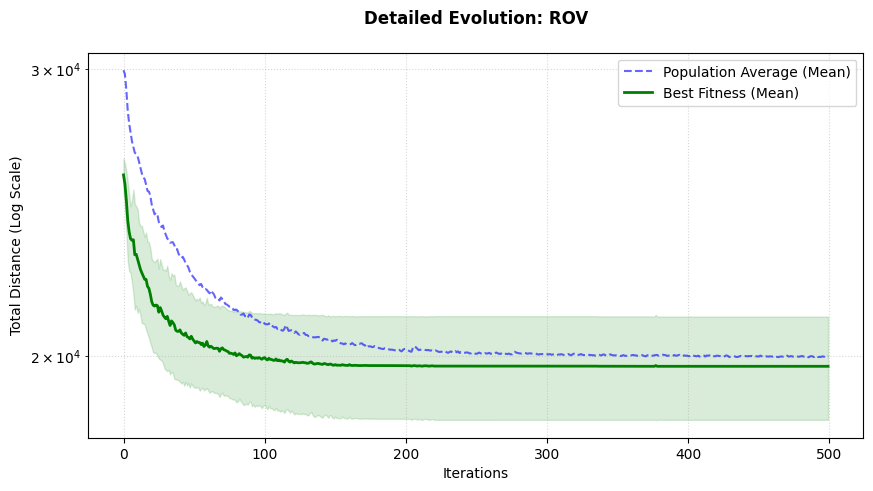

Done! | Gap: 124.07% | Time: 0.76s

                             PSO TSP COMPARATIVE RESULTS                             
Algo                           Config   w  c1  c2  Avg Fit  Min Fit  Gap %  Avg Time (s)  Std Dev
 ROV              Standard (Balanced) 0.8 1.0 1.0 17683.00  14999.0  98.87         0.777  1360.82
 ROV       High Inertia (Exploration) 0.9 0.5 0.6 18661.63  16811.0 122.90         0.799   946.31
 ROV  High Acceleration (Convergence) 0.6 1.8 1.8 16318.77  13123.0  74.00         0.765  1288.81
 ROV Highly Social (Global Influence) 0.7 0.5 2.5 19704.57  16899.0 124.07         0.759  1434.94


In [11]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

rounds_sweep = 30
def_pop = 100
def_iter = 500

results_pso = []
master_results = {}

configs = [
    {'w': 0.8, 'c1': 1.0, 'c2': 1.0, 'desc': 'Standard (Balanced)'}, 
    {'w': 0.9, 'c1': 0.5, 'c2': 0.6, 'desc': 'High Inertia (Exploration)'},
    {'w': 0.6, 'c1': 1.8, 'c2': 1.8, 'desc': 'High Acceleration (Convergence)'},
    {'w': 0.7, 'c1': 0.5, 'c2': 2.5, 'desc': 'Highly Social (Global Influence)'}
]

print(f"Initializing Parameter Sweep - Berlin52 TSP")
print(f"Settings: Pop={def_pop}, Iter={def_iter}, Rounds={rounds_sweep}\n")

print(f"\n>>> Testing Algorithm: {'ROV'}")
for cfg in configs:
    w, c1, c2, desc = cfg['w'], cfg['c1'], cfg['c2'], cfg['desc']
    
    print(f"Running config: {desc} (w:{w}, c1:{c1}, c2:{c2})...", end=" ")
    
    start_time = time.time()
    
    result = run_experiment(algo, def_pop, def_iter, w, c1, c2, rounds=rounds_sweep)
    
    elapsed = time.time() - start_time
    
    results_pso.append({
        'Algo': algo,
        'Config': desc,
        'w': w, 'c1': c1, 'c2': c2,
        'Avg Fit': round(result['avg_fit'], 2),
        'Min Fit': round(result['min_fit'], 2),
        'Gap %': round(result['gap'], 2),
        'Avg Time (s)': round(result['avg_time'], 3),
        'Std Dev': round(result['std_fit'], 2)
    })
    
    label = f"{algo} - {desc}"
    master_results[label] = result
    
    print(f"Done! | Gap: {result['gap']:.2f}% | Time: {result['avg_time']:.2f}s")

df_pso = pd.DataFrame(results_pso)
print("\n" + "="*85)
print(f"{'PSO TSP COMPARATIVE RESULTS':^85}")
print("="*85)
print(df_pso.to_string(index=False))


C:\Users\enric\AppData\Local\Temp\ipykernel_25732\273096248.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(results_master))


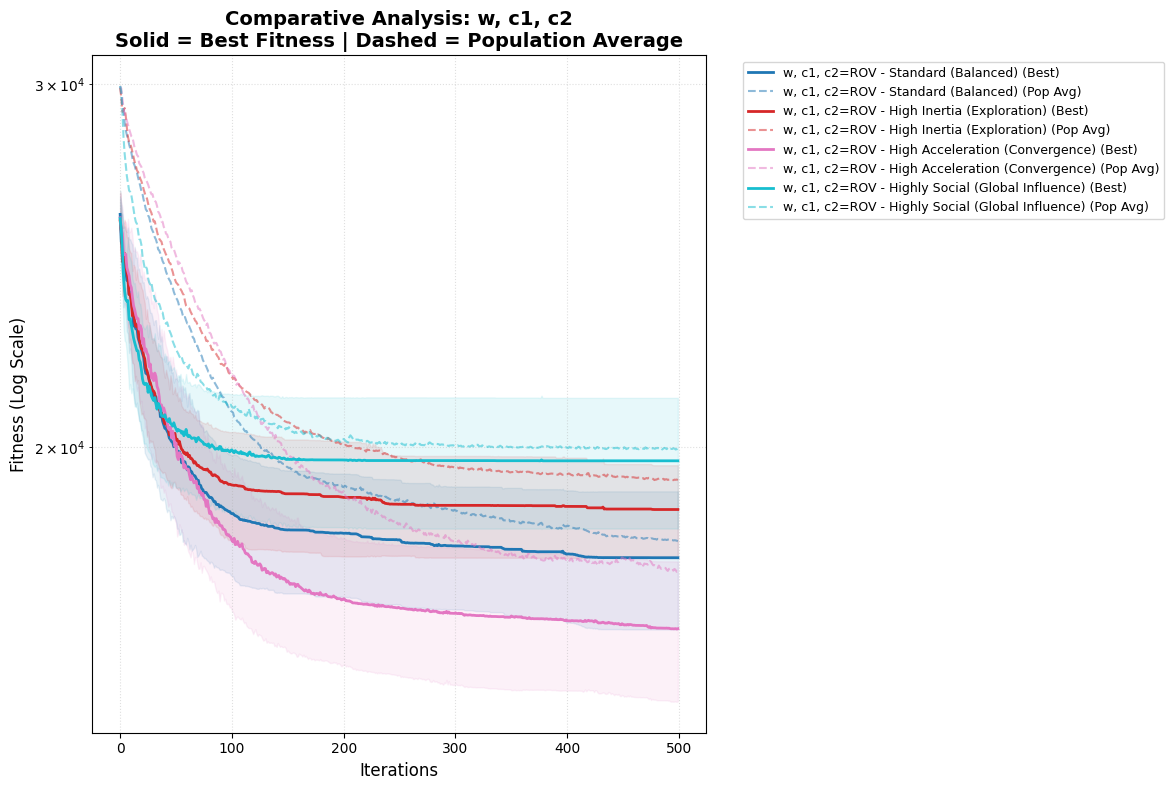

In [12]:
plot_final_comparison(master_results, var_name="w, c1, c2", filename="comparativa_pso_tsp_w.png")

Initializing Parameter Sweep - Berlin52 TSP
Settings: Pop=100, Iter=500, Rounds=30


>>> Testing Algorithm: ROV
Running config: 0.6, 1.8, 1.8 (w:0.6, c1:1.8, c2:1.8)... 

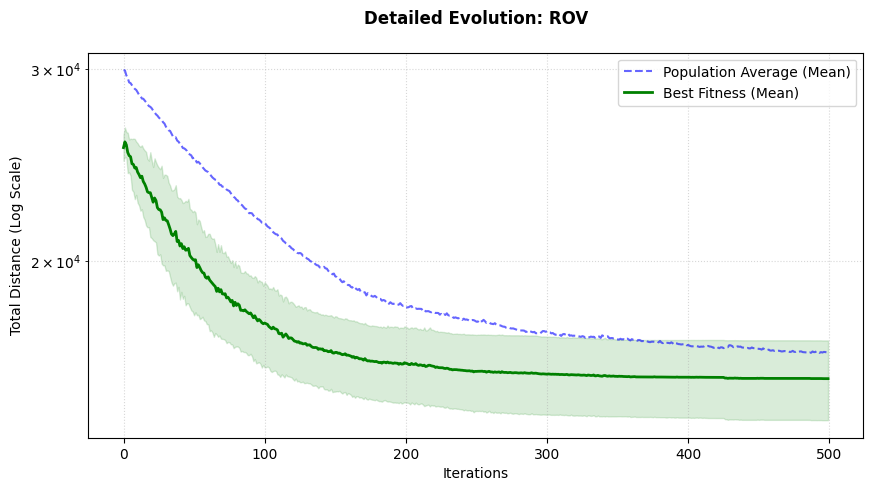

Done! | Gap: 75.59% | Time: 0.72s
Running config: 0.6, 2.0, 2.0 (w:0.6, c1:2.0, c2:2.0)... 

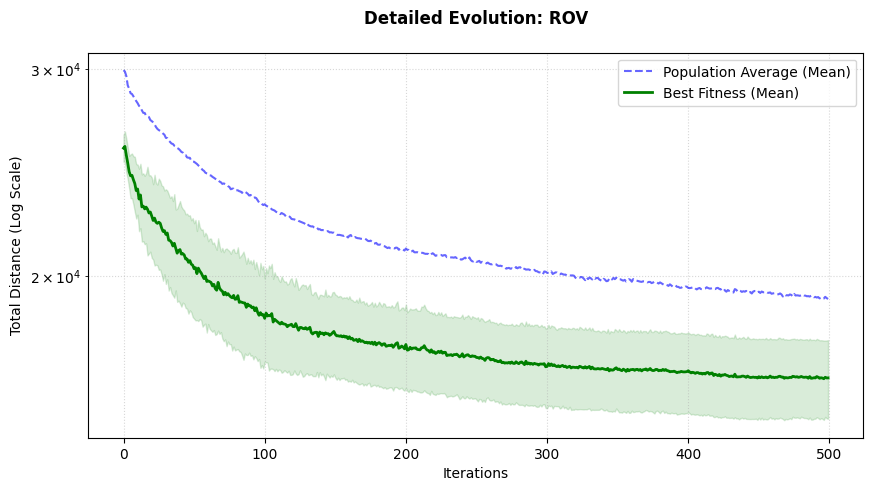

Done! | Gap: 83.93% | Time: 0.71s
Running config: 0.7, 1.8, 1.8 (w:0.7, c1:1.8, c2:1.8)... 

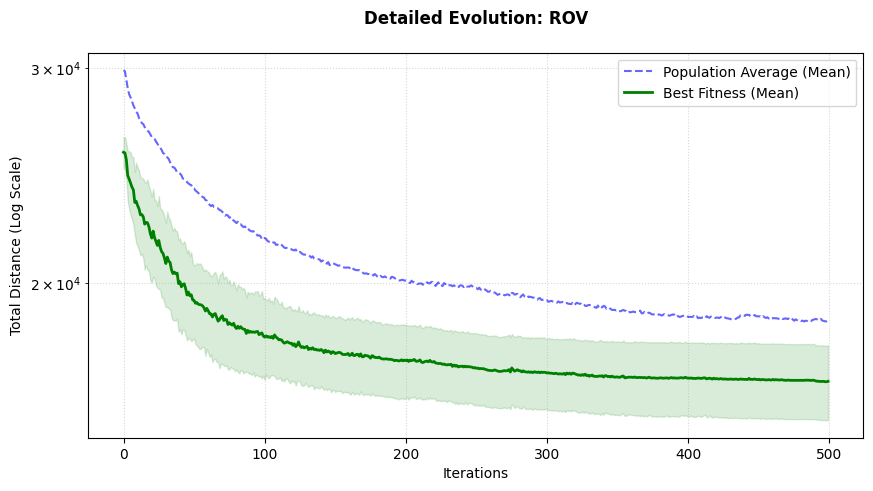

Done! | Gap: 87.66% | Time: 0.71s
Running config: 0.5, 1.8, 1.8 (w:0.5, c1:1.8, c2:1.8)... 

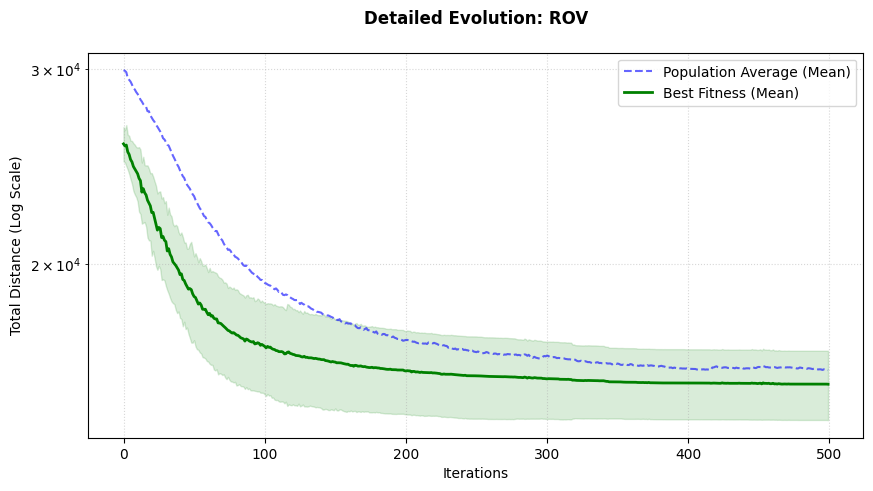

Done! | Gap: 74.89% | Time: 0.70s
Running config: 0.6, 1.0, 1.8 (w:0.6, c1:1.0, c2:1.8)... 

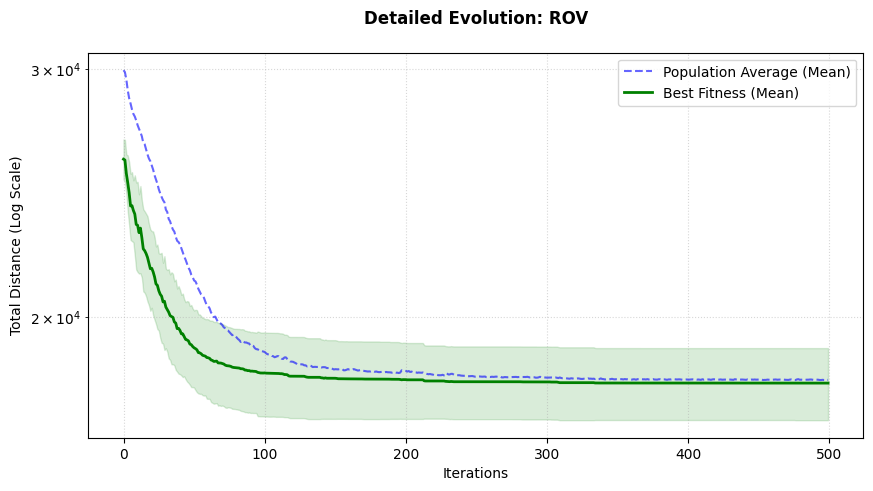

Done! | Gap: 103.45% | Time: 0.70s
Running config: 0.6, 1.8, 1.0 (w:0.6, c1:1.8, c2:1.0)... 

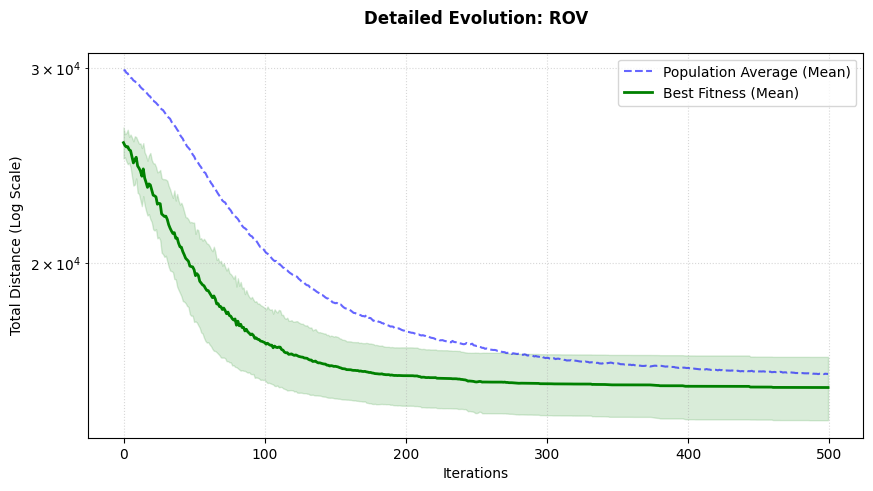

Done! | Gap: 82.42% | Time: 0.69s

                             PSO TSP COMPARATIVE RESULTS                             
Algo        Config   w  c1  c2  Avg Fit  Min Fit  Gap %  Avg Time (s)  Std Dev
 ROV 0.6, 1.8, 1.8 0.6 1.8 1.8 15593.67  13243.0  75.59         0.724  1310.70
 ROV 0.6, 2.0, 2.0 0.6 2.0 2.0 16331.33  13872.0  83.93         0.711  1289.71
 ROV 0.7, 1.8, 1.8 0.7 1.8 1.8 16593.67  14153.0  87.66         0.713  1163.40
 ROV 0.5, 1.8, 1.8 0.5 1.8 1.8 15594.80  13190.0  74.89         0.704  1120.70
 ROV 0.6, 1.0, 1.8 0.6 1.0 1.8 17959.40  15344.0 103.45         0.697  1057.30
 ROV 0.6, 1.8, 1.0 0.6 1.8 1.0 15438.00  13758.0  82.42         0.691  1015.60


C:\Users\enric\AppData\Local\Temp\ipykernel_25732\273096248.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(results_master))


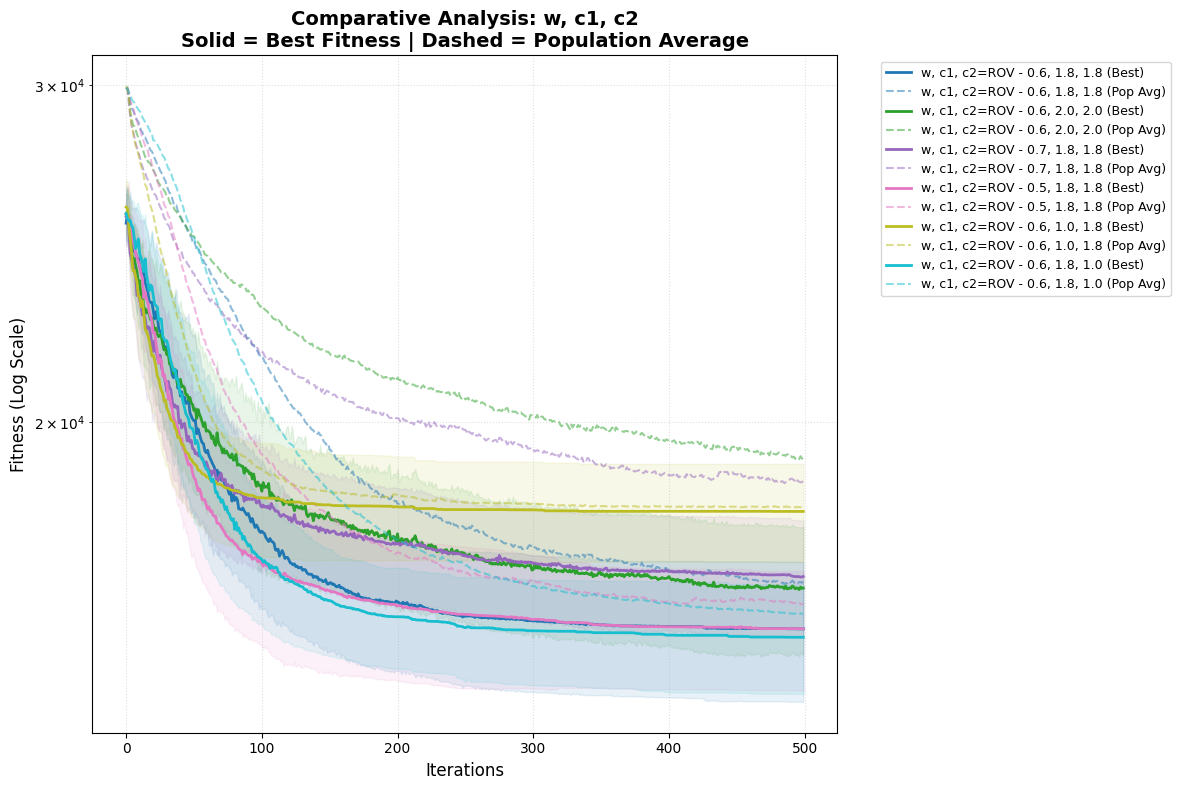

In [13]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

rounds_sweep = 30
def_pop = 100
def_iter = 500
algo = 'ROV'
results_pso = []
master_results = {}

configs = [
    {'w': 0.6, 'c1': 1.8, 'c2': 1.8, 'desc': '0.6, 1.8, 1.8'},
    {'w': 0.6, 'c1': 2.0, 'c2': 2.0, 'desc': '0.6, 2.0, 2.0'},
    {'w': 0.7, 'c1': 1.8, 'c2': 1.8, 'desc': '0.7, 1.8, 1.8'},
    {'w': 0.5, 'c1': 1.8, 'c2': 1.8, 'desc': '0.5, 1.8, 1.8'},
    {'w': 0.6, 'c1': 1.0, 'c2': 1.8, 'desc': '0.6, 1.0, 1.8'},
    {'w': 0.6, 'c1': 1.8, 'c2': 1.0, 'desc': '0.6, 1.8, 1.0'},
]

print(f"Initializing Parameter Sweep - Berlin52 TSP")
print(f"Settings: Pop={def_pop}, Iter={def_iter}, Rounds={rounds_sweep}\n")

print(f"\n>>> Testing Algorithm: {'ROV'}")
for cfg in configs:
    w, c1, c2, desc = cfg['w'], cfg['c1'], cfg['c2'], cfg['desc']
    
    print(f"Running config: {desc} (w:{w}, c1:{c1}, c2:{c2})...", end=" ")
    
    start_time = time.time()
    
    result = run_experiment(algo, def_pop, def_iter, w, c1, c2, rounds=rounds_sweep)
    
    elapsed = time.time() - start_time
    
    results_pso.append({
        'Algo': algo,
        'Config': desc,
        'w': w, 'c1': c1, 'c2': c2,
        'Avg Fit': round(result['avg_fit'], 2),
        'Min Fit': round(result['min_fit'], 2),
        'Gap %': round(result['gap'], 2),
        'Avg Time (s)': round(result['avg_time'], 3),
        'Std Dev': round(result['std_fit'], 2)
    })
    
    label = f"{algo} - {desc}"
    master_results[label] = result
    
    print(f"Done! | Gap: {result['gap']:.2f}% | Time: {result['avg_time']:.2f}s")

df_pso = pd.DataFrame(results_pso)
print("\n" + "="*85)
print(f"{'PSO TSP COMPARATIVE RESULTS':^85}")
print("="*85)
print(df_pso.to_string(index=False))
plot_final_comparison(master_results, var_name="w, c1, c2", filename="comparativa_final_pso_tsp_w.png")

### **Testing on Population**

Initializing Parameter Sweep - Berlin52 TSP
Settings: Pop=100, Iter=500, Rounds=30


>>> Testing Algorithm: ROV
Running config: Pop=30... 

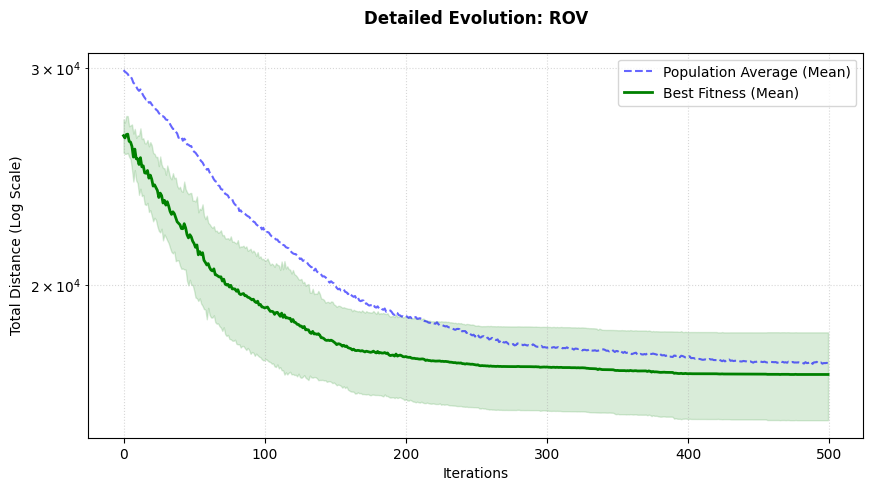

Done! | Gap: 89.27% | Time: 0.21s
Running config: Pop=50... 

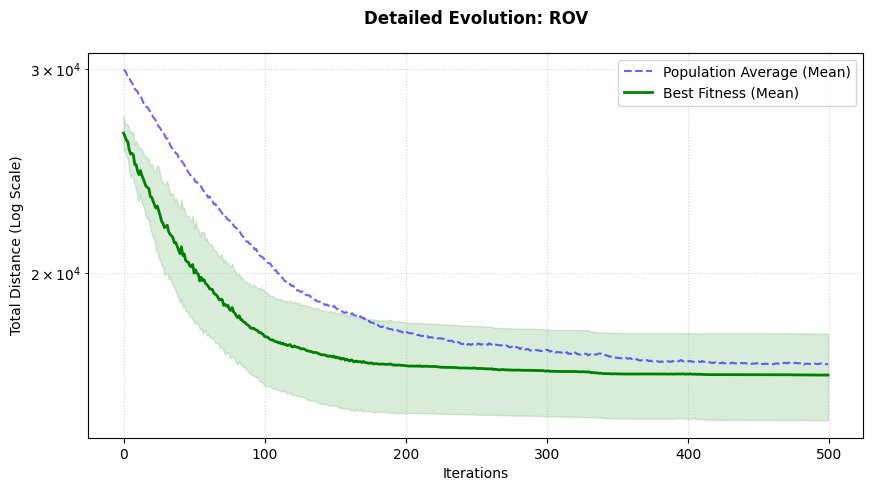

Done! | Gap: 80.07% | Time: 0.35s
Running config: Pop=200... 

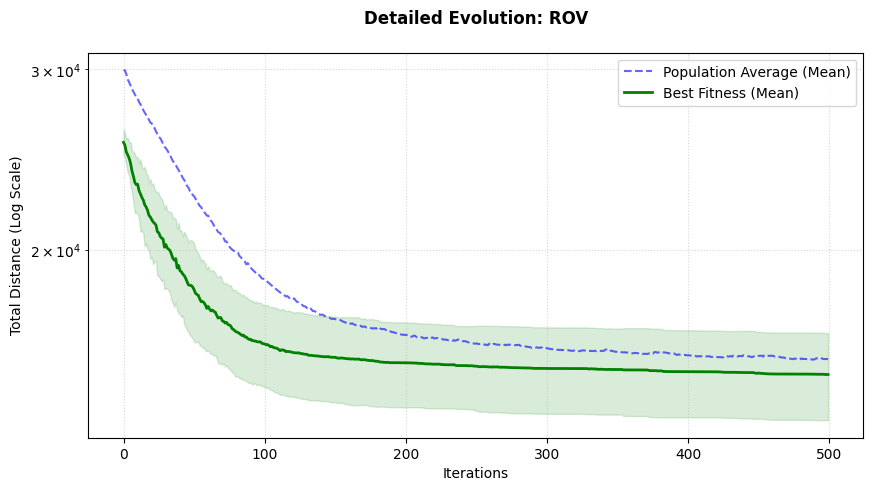

Done! | Gap: 54.31% | Time: 1.57s
Running config: Pop=600... 

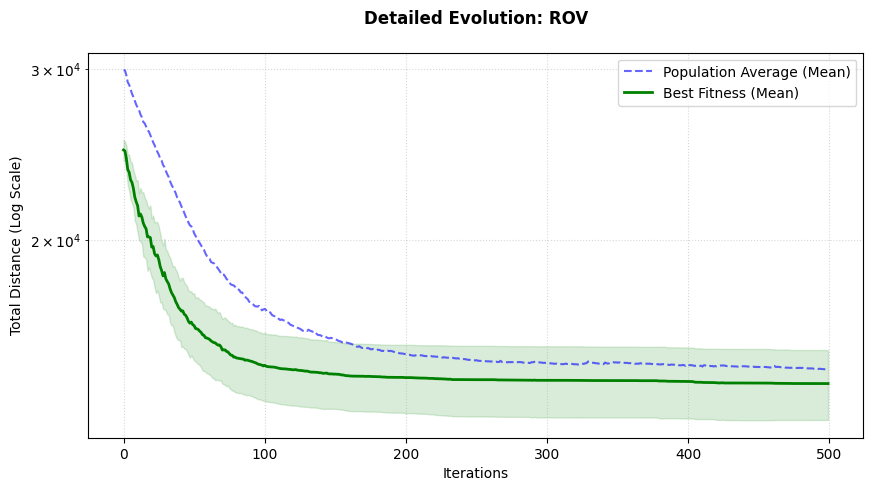

Done! | Gap: 59.03% | Time: 4.49s

                             PSO TSP COMPARATIVE RESULTS                             
Algo  Config   w  c1  c2  Avg Fit  Min Fit  Gap %  Avg Time (s)  Std Dev
 ROV  Pop=30 0.5 1.8 1.8 16914.17  14275.0  89.27         0.214  1387.14
 ROV  Pop=50 0.5 1.8 1.8 16340.40  13581.0  80.07         0.350  1400.23
 ROV Pop=200 0.5 1.8 1.8 15130.27  11638.0  54.31         1.572  1474.96
 ROV Pop=600 0.5 1.8 1.8 14235.60  11994.0  59.03         4.485  1178.02


C:\Users\enric\AppData\Local\Temp\ipykernel_25732\273096248.py:90: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(results_master))


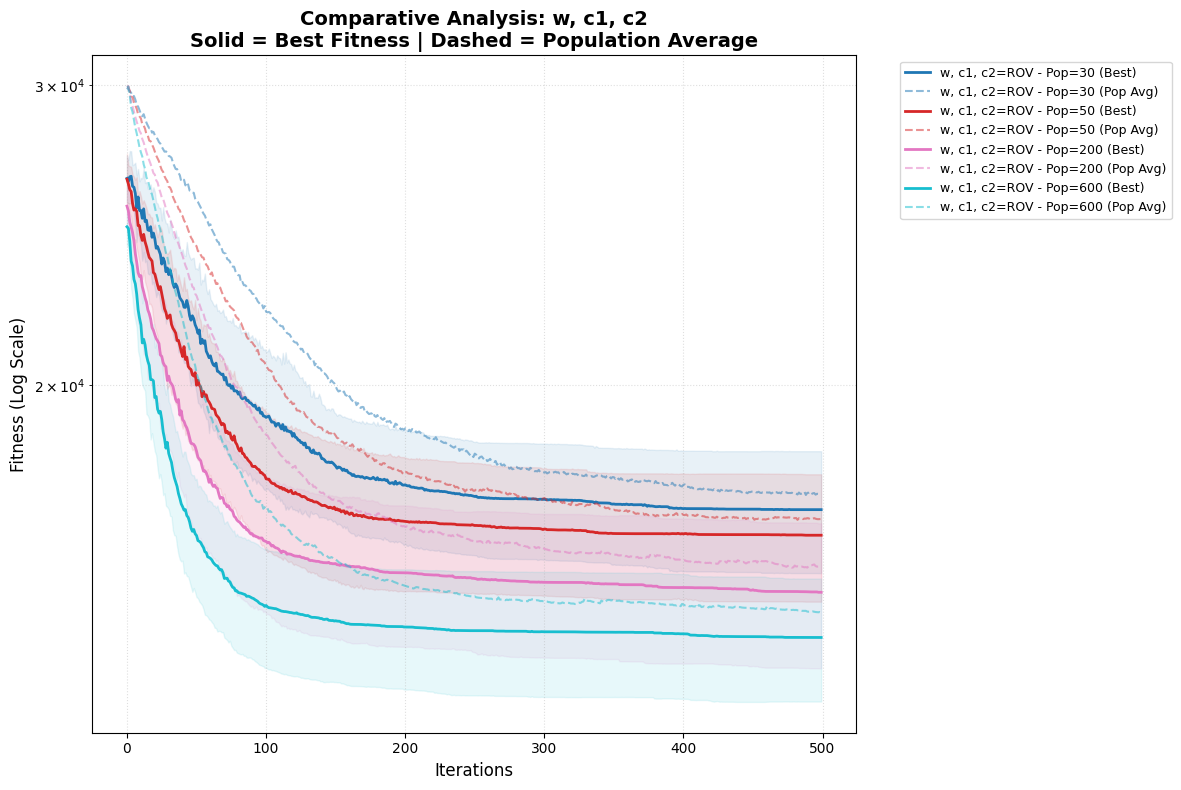

In [15]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

rounds_sweep = 30
def_iter = 500
algo = 'ROV'
results_pso = []
master_results = {}
w_def = 0.5
c1_def = 1.8
c2_def = 1.8
pop_configs =  [30, 50, 200, 600]

print(f"Initializing Parameter Sweep - Berlin52 TSP")
print(f"Settings: Pop={def_pop}, Iter={def_iter}, Rounds={rounds_sweep}\n")

print(f"\n>>> Testing Algorithm: {'ROV'}")
for pop in pop_configs:
    print(f"Running config: Pop={pop}...", end=" ")
        
    start_time = time.time()
    
    result = run_experiment(algo, pop, def_iter, w_def, c1_def, c2_def, rounds=rounds_sweep)
    
    elapsed = time.time() - start_time
    
    results_pso.append({
        'Algo': algo,
        'Config': f"Pop={pop}",
        'w': w_def, 'c1': c1_def, 'c2': c2_def,
        'Avg Fit': round(result['avg_fit'], 2),
        'Min Fit': round(result['min_fit'], 2),
        'Gap %': round(result['gap'], 2),
        'Avg Time (s)': round(result['avg_time'], 3),
        'Std Dev': round(result['std_fit'], 2)
    })
    
    label = f"{algo} - Pop={pop}"
    master_results[label] = result
    
    print(f"Done! | Gap: {result['gap']:.2f}% | Time: {result['avg_time']:.2f}s")

df_pso = pd.DataFrame(results_pso)
print("\n" + "="*85)
print(f"{'PSO TSP COMPARATIVE RESULTS':^85}")
print("="*85)
print(df_pso.to_string(index=False))
plot_final_comparison(master_results, var_name="w, c1, c2", filename="comparativa_final_pso_tsp_pop.png")

### **Pareto Front**

Starting PSO experiments on berlin52...


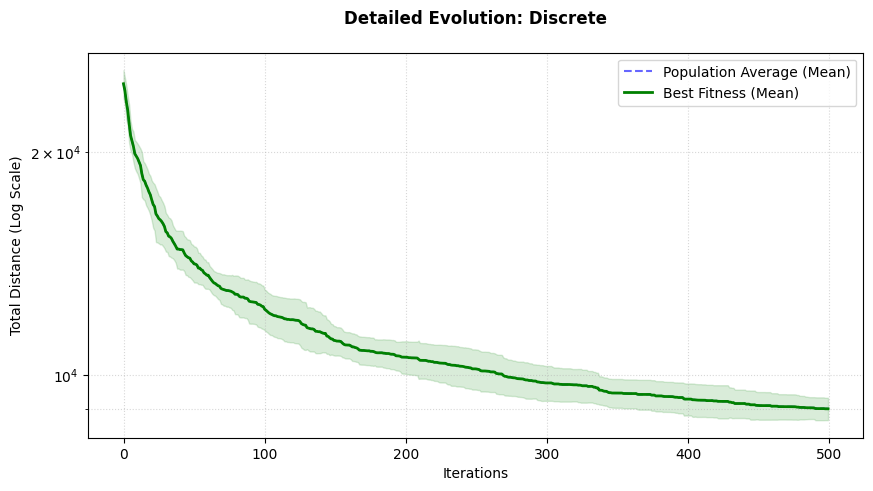

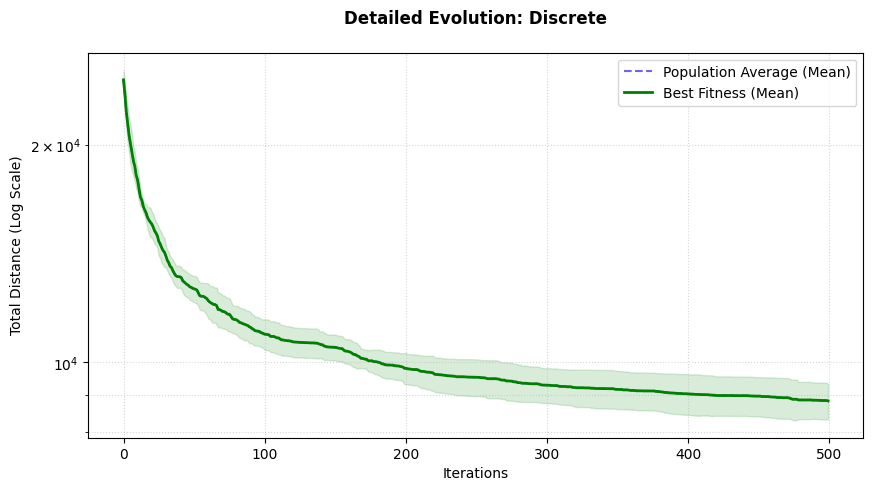

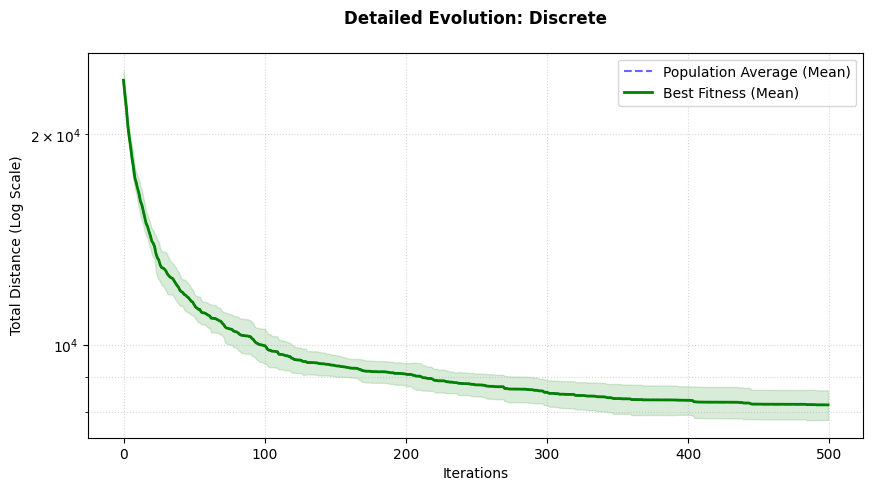

       type  pop  iter  avg_fit  min_fit     std_fit  avg_time        gap
0  Discrete   50   500   8996.6   8670.0  312.414852  1.544327  14.956245
1  Discrete  100   500   8844.1   8282.0  498.719250  3.084219   9.811721
2  Discrete  200   500   8202.7   7542.0  400.583587  6.144991   0.000000


In [19]:
# Parameters to test
filename = 'berlin52'


pop_sizes = [50, 100, 200]
max_iter = 500
results_pso = []


print(f"Starting PSO experiments on {filename}...")
for pop in pop_sizes:
    res = run_experiment('Discrete', pop, max_iter,0.8, 1.5, 1.5)
    res['type'] = 'Discrete'
    res['pop'] = pop
    res['iter'] = max_iter
    results_pso.append(res)
    

df = pd.DataFrame(results_pso)
print(df[['type', 'pop', 'iter', 'avg_fit', 'min_fit', 'std_fit', 'avg_time', 'gap']])


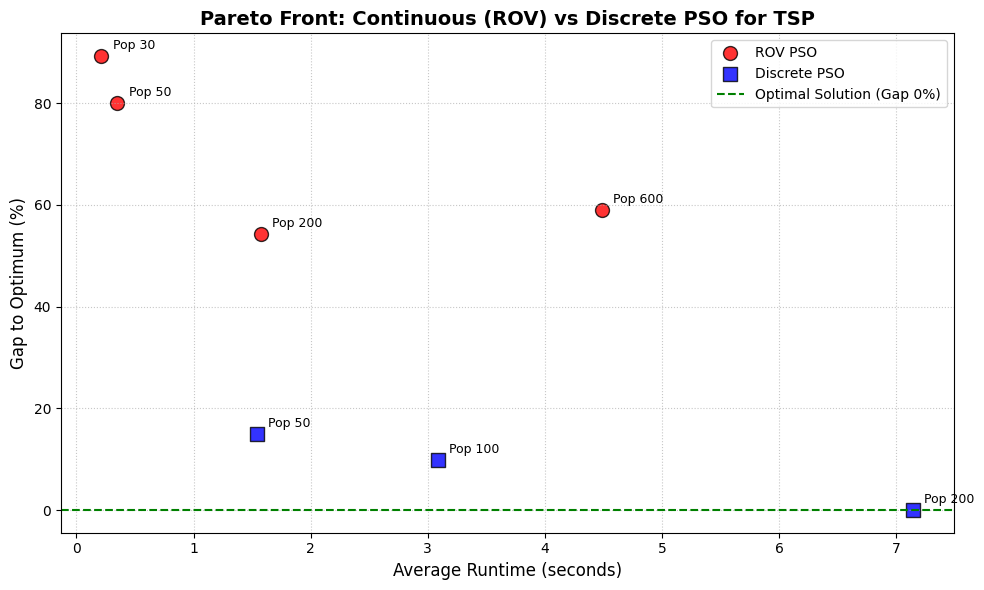

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

data_rov = [
    {'Algorithm': 'ROV', 'Config': 'Pop 30',  'Time': 0.214, 'Gap': 89.27},
    {'Algorithm': 'ROV', 'Config': 'Pop 50',  'Time': 0.350, 'Gap': 80.07},
    {'Algorithm': 'ROV', 'Config': 'Pop 200', 'Time': 1.572, 'Gap': 54.31},
    {'Algorithm': 'ROV', 'Config': 'Pop 600', 'Time': 4.485, 'Gap': 59.03} 
]


data_discrete = [
    {'Algorithm': 'Discrete', 'Config': 'Pop 50',  'Time': 1.544, 'Gap': 14.9},
    {'Algorithm': 'Discrete', 'Config': 'Pop 100', 'Time': 3.084, 'Gap': 9.81},
    {'Algorithm': 'Discrete', 'Config': 'Pop 200', 'Time': 7.145, 'Gap': 0.0}
]


df_pareto = pd.DataFrame(data_rov + data_discrete)

plt.figure(figsize=(10, 6))

colors = {'ROV': 'red', 'Discrete': 'blue'}
markers = {'ROV': 'o', 'Discrete': 's'}

for algo in df_pareto['Algorithm'].unique():
    subset = df_pareto[df_pareto['Algorithm'] == algo]
    plt.scatter(subset['Time'], subset['Gap'], 
                label=f"{algo} PSO", 
                color=colors[algo], 
                marker=markers[algo], 
                s=100, alpha=0.8, edgecolor='black')
    
    for i, row in subset.iterrows():
        plt.annotate(row['Config'], 
                     (row['Time'], row['Gap']), 
                     xytext=(8, 5), textcoords='offset points', 
                     fontsize=9)

plt.title('Pareto Front: Continuous (ROV) vs Discrete PSO for TSP', fontsize=14, fontweight='bold')
plt.xlabel('Average Runtime (seconds)', fontsize=12)
plt.ylabel('Gap to Optimum (%)', fontsize=12)

plt.axhline(0, color='green', linestyle='--', linewidth=1.5, label='Optimal Solution (Gap 0%)')

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('pareto_front_pso.png', dpi=300)
plt.show()